# 🔗 Cross-Platform Profile Matching with SBERT-MPNet

**เป้าหมาย**: เชื่อมโยงโปรไฟล์จาก Twitter / Instagram / Google+ ที่เป็นคนเดียวกัน
โดยใช้ `all-mpnet-base-v2` (SBERT-MPNet) ตามงานวิจัย Social-LLM

**Pipeline**:
1. โหลดข้อมูล → 2. ทำความสะอาด Bio → 3. Enrich Profile Text
4. สร้าง Embeddings (768 มิติ) → 5. FAISS Index → 6. Cross-Platform Matching
7. คะแนนความเหมือน → 8. บันทึกผลลัพธ์

In [2]:
# ===== Cell 1: ติดตั้ง packages ทั้งหมด =====
import subprocess, sys

packages = [
    'numpy', 'pandas', 'regex', 'ftfy', 'rapidfuzz',
    'unidecode', 'emoji', 'langdetect',
    'faiss-cpu', 'sentence-transformers', 'keybert',
    'certifi', 'huggingface_hub', 'requests',
    'matplotlib', 'seaborn', 'scikit-learn'
]

for pkg in packages:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       capture_output=True, text=True)
    status = '✅' if r.returncode == 0 else '⚠️'
    print(f'{status} {pkg}')

print('\n=== Done ===')

✅ numpy
✅ pandas
✅ regex
✅ ftfy
✅ rapidfuzz
✅ unidecode
✅ emoji
✅ langdetect
✅ faiss-cpu
✅ sentence-transformers
✅ keybert
✅ certifi
✅ huggingface_hub
✅ requests
✅ matplotlib
✅ seaborn
✅ scikit-learn

=== Done ===


In [3]:
# ===== Cell 2: Import ทั้งหมด =====
import os, re, math, json, warnings
import ssl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ftfy import fix_text
from unidecode import unidecode
import emoji
from rapidfuzz import fuzz
from langdetect import detect, LangDetectException

import faiss
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Fix SSL สำหรับ Windows
os.environ['CURL_CA_BUNDLE'] = ''
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except:
    pass

print('All imports OK ✅')

d:\66070260-Year3_Term2\Project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\66070260-Year3_Term2\Project1\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):



All imports OK ✅


---
## 1. โหลดข้อมูล

In [4]:
# โหลดจาก CSV ที่เตรียมไว้ (เร็วกว่าอ่าน JSON 23,000+ ไฟล์)
df = pd.read_csv('data/combined_profiles.csv')

print(f'Total profiles: {len(df):,}')
print(f'Platforms: {df["platform"].value_counts().to_dict()}')
print(f'\n--- Non-null counts ---')
print(df.count())
df.head(3)

Total profiles: 24,729
Platforms: {'twitter': 8535, 'googleplus': 8302, 'instagram': 7892}

--- Non-null counts ---
userName             24668
fullName             24420
bigrams              24729
source_folder        24729
user_folder          24726
platform             24729
bio                  20348
externalUrl          20832
outputProfileName    16425
pictureURL           16304
location              7938
dtype: int64


,userName,fullName,bigrams,source_folder,user_folder,platform,bio,externalUrl,outputProfileName,pictureURL,location
0,i3mawi,Adeeb Amawi,"['i3', '3m', 'ma', 'aw', 'wi', 'Ad', 'de', 'ee...",1.profile.data,A3mawi,googleplus,NaN,NaN,NaN,NaN,NaN
1,WoltersKluwerEspaa,Wolters Kluwer Espaa,"['Wo', 'ol', 'lt', 'te', 'er', 'rs', 'sK', 'Kl...",1.profile.data,A3Software,googleplus,NaN,NaN,NaN,NaN,NaN
2,AALISHANMATRIX,AALISHAN MATRIX,"['AA', 'AL', 'LI', 'IS', 'SH', 'HA', 'AN', 'NM...",1.profile.data,aalishanmatrix,googleplus,"Computer scientist, Aspiring entrepreneur & in...",['http://www.siliconindia.com/profiles/aalisha...,NaN,NaN,NaN


---
## 2. Text Cleaning & Profile Enrichment

In [5]:
# ===== Text Cleaning Functions =====

URL_RE = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')  # keep the word, remove #
MULTISPACE_RE = re.compile(r'\s+')


def safe_str(value) -> str:
    """Convert any value to safe string"""
    if value is None:
        return ''
    if isinstance(value, float) and math.isnan(value):
        return ''
    return str(value).strip()


def clean_bio(text) -> str:
    """ทำความสะอาด bio text"""
    text = safe_str(text)
    if not text or text.lower() == 'none':
        return ''
    
    text = fix_text(text)                        # Fix broken unicode
    text = URL_RE.sub(' ', text)                  # Remove URLs
    text = MENTION_RE.sub(' ', text)              # Remove @mentions
    text = HASHTAG_RE.sub(r'\1', text)            # #hashtag → hashtag
    text = emoji.demojize(text, delimiters=(' ', ' '))  # 🎨 → art
    text = text.replace('\u200b', ' ')            # Zero-width space
    text = MULTISPACE_RE.sub(' ', text).strip()
    
    return text if len(text) >= 3 else ''


def normalize_name(name) -> str:
    """Normalize ชื่อสำหรับเปรียบเทียบ"""
    name = safe_str(name).lower()
    name = re.sub(r'[^a-z0-9\s\u0E00-\u0E7F]', ' ', name)  # Keep alpha + Thai
    return MULTISPACE_RE.sub(' ', name).strip()


def extract_domain(url) -> str:
    """ดึง domain จาก URL"""
    url = safe_str(url)
    if not url:
        return ''
    match = re.search(r'(?:https?://)?(?:www\.)?([^/]+)', url)
    if match:
        return match.group(1).lower()
    return ''


print('Text cleaning functions defined ✅')

Text cleaning functions defined ✅


In [6]:
# ===== Profile Enrichment =====
# รวมข้อมูลทุกอย่างเป็น enriched text เพื่อให้ SBERT จับ semantic ได้ดีขึ้น

def enrich_profile(row) -> str:
    """
    รวม bio + username + fullName + location + externalUrl
    → enriched text สำหรับ embedding
    
    ข้อมูลแต่ละส่วนช่วยให้ matching แม่นยำขึ้น:
    - bio: ความชอบ, อาชีพ, บุคลิก (สำคัญที่สุด)
    - fullName: ชื่อจริง (ช่วยยืนยันตัวตน)
    - location: ที่อยู่ (narrowing down)
    - externalUrl: เว็บไซต์ส่วนตัว (strong signal)
    """
    parts = []
    
    # Bio (most important - ใส่ก่อน)
    bio = clean_bio(row.get('bio', ''))
    if bio:
        parts.append(bio)
    
    # Full Name
    name = normalize_name(row.get('fullName', ''))
    if name:
        parts.append(f'name: {name}')
    
    # Location
    loc = safe_str(row.get('location', ''))
    if loc and loc.lower() != 'none':
        parts.append(f'location: {loc}')
    
    # External URL (domain only)
    domain = extract_domain(row.get('externalUrl', ''))
    if domain:
        parts.append(f'website: {domain}')
    
    return ' | '.join(parts) if parts else ''


# Apply
df['bio_clean'] = df['bio'].apply(clean_bio)
df['enriched_text'] = df.apply(enrich_profile, axis=1)

# สถิติ
has_bio = (df['bio_clean'] != '').sum()
has_enriched = (df['enriched_text'] != '').sum()

print(f'Profiles with clean bio: {has_bio:,} / {len(df):,}')
print(f'Profiles with enriched text: {has_enriched:,} / {len(df):,}')
print(f'\n--- ตัวอย่าง enriched text ---')
for i, row in df[df['enriched_text'] != ''].head(5).iterrows():
    print(f'[{row["platform"]:>10}] {row["enriched_text"][:120]}...')

Profiles with clean bio: 20,213 / 24,729
Profiles with enriched text: 24,530 / 24,729

--- ตัวอย่าง enriched text ---
[googleplus] name: adeeb amawi...
[googleplus] name: wolters kluwer espaa...
[googleplus] Computer scientist, Aspiring entrepreneur & innovator, Former PHP technical writer, Currently an Genius Cloud geek Golde...
[   twitter] Co-Founder & Full Stack CEO , the B2B marketing attribution company. Uniting marketing & sales one company at a time. | ...
[ instagram] name: acfoto | website: aaroncodling.com...


---
## 3. SBERT-MPNet Embedding (768 มิติ)

ใช้ `all-mpnet-base-v2` ตามที่งานวิจัย Social-LLM แนะนำ:
- เข้าใจ **ความหมาย** ไม่ใช่แค่คำศัพท์
- ประสิทธิภาพสูงสุด (Macro-F1 สูงกว่า RoBERTa, BERTweet)
- รองรับข้อความสั้น (bio) ได้ดี

In [7]:
# ===== โหลด SBERT-MPNet =====
# all-mpnet-base-v2: Best quality sentence embeddings (768 dim)
import torch
MODEL_NAME = 'all-mpnet-base-v2'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer(MODEL_NAME, device=device)

try:
    model = SentenceTransformer(MODEL_NAME)
    print(f'Model: {MODEL_NAME}')
    print(f'Embedding dimension: {model.get_sentence_embedding_dimension()}')
    print(f'Max sequence length: {model.max_seq_length}')
    print(f'Device: {device} {"🚀 GPU" if device == "cuda" else "🐢 CPU"}')
    print(f'GPU: {torch.cuda.get_device_name(0)}' if device == 'cuda' else '')
    print('Model loaded ✅')
except Exception as e:
    print(f'Error: {e}')
    print('ลอง Restart Kernel แล้วรัน cell install ใหม่')

Model: all-mpnet-base-v2
Embedding dimension: 768
Max sequence length: 384
Device: cuda 🚀 GPU
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Model loaded ✅


In [8]:
# ===== Quick Demo: ทดสอบว่า Model เข้าใจ "ความหมาย" =====

demo_pairs = [
    ('Software Engineer', 'Coding Life'),
    ('AI Researcher | Love Coding & Coffee', 'Ph.D. Student in Machine Learning'),
    ('Photographer | Travel lover', 'Full Stack Developer'),
    ('Bangkok, Thailand', 'กรุงเทพ'),
]

print('=== Semantic Understanding Demo ===')
print(f'Model: {MODEL_NAME}\n')

for text_a, text_b in demo_pairs:
    emb_a = model.encode(text_a)
    emb_b = model.encode(text_b)
    score = util.cos_sim(emb_a, emb_b).item()
    bar = '█' * int(score * 30)
    print(f'  "{text_a}"')
    print(f'  "{text_b}"')
    print(f'  Similarity: {score:.4f} {bar}\n')

=== Semantic Understanding Demo ===
Model: all-mpnet-base-v2

  "Software Engineer"
  "Coding Life"
  Similarity: 0.4884 ██████████████

  "AI Researcher | Love Coding & Coffee"
  "Ph.D. Student in Machine Learning"
  Similarity: 0.4544 █████████████

  "Photographer | Travel lover"
  "Full Stack Developer"
  Similarity: 0.1689 █████

  "Bangkok, Thailand"
  "กรุงเทพ"
  Similarity: 0.2449 ███████



In [9]:
# ===== สร้าง Embeddings สำหรับทุก Profile =====

# ใช้เฉพาะ profiles ที่มี enriched text
df_valid = df[df['enriched_text'] != ''].copy().reset_index(drop=True)
texts = df_valid['enriched_text'].tolist()

print(f'Encoding {len(texts):,} profiles with {MODEL_NAME} on {device}...')
# GPU สามารถใช้ batch_size ใหญ่ขึ้นได้ (128-256)
embeddings = model.encode(
    texts,
    batch_size=256 if device == 'cuda' else 64,  # GPU ใช้ batch ใหญ่ขึ้น
    show_progress_bar=True,
    normalize_embeddings=True,    # L2 normalize → cosine sim = dot product
    convert_to_numpy=True,
    device=device                 # ระบุ device ตรงนี้ด้วย
).astype(np.float32)
print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'  → {embeddings.shape[0]:,} profiles × {embeddings.shape[1]} dimensions')
print('Done ✅')

Encoding 24,530 profiles with all-mpnet-base-v2 on cuda...


Batches: 100%|██████████| 96/96 [03:51<00:00,  2.41s/it]



Embeddings shape: (24530, 768)
  → 24,530 profiles × 768 dimensions
Done ✅


---
## 4. FAISS Index & Similarity Search

In [10]:
# ===== สร้าง FAISS Index =====
# ใช้ Inner Product เพราะ embeddings ถูก normalize แล้ว
# → cosine similarity = dot product

dimension = embeddings.shape[1]  # 768
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print(f'FAISS Index created ✅')
print(f'  Vectors: {index.ntotal:,}')
print(f'  Dimension: {dimension}')

FAISS Index created ✅
  Vectors: 24,530
  Dimension: 768


In [11]:
# ===== Function: ค้นหา Profiles ที่คล้ายกัน =====

def search_similar(query, top_k=10, platform_filter=None):
    """
    ค้นหา profiles ที่คล้ายกับ query text
    
    Args:
        query: ข้อความค้นหา หรือ index ของ profile
        top_k: จำนวนผลลัพธ์
        platform_filter: กรองเฉพาะ platform (เช่น 'twitter')
    """
    if isinstance(query, str):
        q_emb = model.encode([query], normalize_embeddings=True).astype(np.float32)
    elif isinstance(query, int):
        q_emb = embeddings[query:query+1]
    else:
        q_emb = query.reshape(1, -1).astype(np.float32)
    
    # Search more if filtering
    search_k = top_k * 5 if platform_filter else top_k
    scores, indices = index.search(q_emb, min(search_k, index.ntotal))
    
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        row = df_valid.iloc[idx]
        if platform_filter and row['platform'] != platform_filter:
            continue
        results.append({
            'idx': idx,
            'similarity': round(float(score), 4),
            'userName': row['userName'],
            'fullName': row.get('fullName', ''),
            'platform': row['platform'],
            'bio': str(row['bio_clean'])[:80],
            'location': safe_str(row.get('location', '')),
        })
        if len(results) >= top_k:
            break
    
    return pd.DataFrame(results)


# ===== ทดสอบค้นหา =====
print('🔍 Query: "software engineer AI machine learning"')
search_similar('software engineer AI machine learning', top_k=10)

🔍 Query: "software engineer AI machine learning"


,idx,similarity,userName,fullName,platform,bio,location
0,13952,0.5433,KshitijKhanna,Kshitij Khanna,googleplus,A computer Science engineer currently placed w...,
1,14026,0.5259,@kyrcha,Kyr. Chatzidimitriou,twitter,"Intelligent Systems, Data and Software Enginee...",Thessaloniki
2,1209,0.5221,rorylewis,Rory Lewis,googleplus,Artificial Intelligence & Machine Learning Uni...,
3,24411,0.5184,ZekeriyaKO,Zekeriya KO,googleplus,Experienced Software Developer Celal Bayar niv...,
4,12731,0.5170,PrasannaJayananthan,Prasanna Jayananthasarma,googleplus,"Software Engineer, Eyepax IT Consulting (Pvt) ...",
5,8525,0.5075,FrankJDrring,Frank J. Drring,googleplus,Software Engineer - Web Worker condero Aktieng...,
6,21084,0.5027,ShanMoorthy,Shan Moorthy,googleplus,"Purveyor of geekery; tech addict, and hack fan...",
7,21262,0.5022,@gastronomy,Tanat Tonguthaisri,twitter,"an Epicure & CISSP, interested in TheArtOfPlat...",NSTDA Academy
8,6370,0.4823,DavidFernandez86,David Fernandez,googleplus,ESADE Executive Master en Digital Business Eng...,
9,23350,0.4811,@VishalTx,Vishal Kumar,twitter,TagLover Hacker Innovator DataNerd Entrepreneu...,Boston


---
## 5. Cross-Platform Profile Matching

จับคู่ profiles ข้ามแพลตฟอร์ม — หา profiles ที่น่าจะเป็น **คนเดียวกัน**

**Scoring** ใช้ weighted combination:
- Bio Semantic Similarity (SBERT) — 50%
- Name Similarity (RapidFuzz) — 25%
- Username Similarity — 15%
- Location + URL Match — 10%

In [12]:
# ===== Similarity Features =====

def name_similarity(name1, name2) -> float:
    """เปรียบเทียบชื่อ (token sort ratio)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    if not n1 or not n2:
        return 0.0
    return fuzz.token_sort_ratio(n1, n2) / 100.0


def username_similarity(user1, user2) -> float:
    """เปรียบเทียบ username"""
    u1 = safe_str(user1).lower().strip('@')
    u2 = safe_str(user2).lower().strip('@')
    if not u1 or not u2:
        return 0.0
    # ลอง partial match ด้วย (เพราะ username อาจต่างกันเล็กน้อย)
    exact = fuzz.ratio(u1, u2) / 100.0
    partial = fuzz.partial_ratio(u1, u2) / 100.0
    return max(exact, partial * 0.8)


def location_similarity(loc1, loc2) -> float:
    """เปรียบเทียบ location"""
    l1 = safe_str(loc1).lower()
    l2 = safe_str(loc2).lower()
    if not l1 or not l2 or l1 == 'none' or l2 == 'none':
        return 0.0
    return fuzz.partial_ratio(l1, l2) / 100.0


def url_match(url1, url2) -> float:
    """ตรวจสอบว่า URL ชี้ไปที่เดียวกัน"""
    d1 = extract_domain(url1)
    d2 = extract_domain(url2)
    if not d1 or not d2:
        return 0.0
    return 1.0 if d1 == d2 else fuzz.ratio(d1, d2) / 100.0


def compute_match_score(source_row, target_row, bio_sim) -> dict:
    """
    คำนวณ weighted match score
    
    Weights (ตามงานวิจัย Social-LLM):
    - bio_semantic: 0.50  (สำคัญที่สุด - ความหมายของ bio)
    - name:         0.25  (ชื่อจริงตรงกัน = strong signal)
    - username:     0.15  (username คล้ายกัน)
    - location_url: 0.10  (ข้อมูลเสริม)
    """
    name_sim = name_similarity(source_row.get('fullName', ''), target_row.get('fullName', ''))
    user_sim = username_similarity(source_row.get('userName', ''), target_row.get('userName', ''))
    loc_sim = location_similarity(source_row.get('location', ''), target_row.get('location', ''))
    url_sim = url_match(source_row.get('externalUrl', ''), target_row.get('externalUrl', ''))
    
    # Weighted combination
    loc_url_sim = max(loc_sim, url_sim)  # ใช้ค่าที่สูงกว่า
    
    final_score = (
        0.50 * bio_sim +
        0.25 * name_sim +
        0.15 * user_sim +
        0.10 * loc_url_sim
    )
    
    return {
        'final_score': round(final_score, 4),
        'bio_semantic': round(bio_sim, 4),
        'name_sim': round(name_sim, 4),
        'username_sim': round(user_sim, 4),
        'location_sim': round(loc_sim, 4),
        'url_sim': round(url_sim, 4),
    }


print('Matching functions defined ✅')

Matching functions defined ✅


In [13]:
# ===== Cross-Platform Matching Pipeline =====
# จับคู่ profiles จาก platform A → platform B

def match_cross_platform(
    source_platform='twitter',
    target_platform='instagram',
    top_k_candidates=20,     # จำนวน candidates จาก FAISS
    threshold=0.45,          # minimum score เพื่อถือว่า "match"
    max_source=None          # จำกัดจำนวน source (None = ทั้งหมด)
):
    """
    Pipeline:
    1. ดึง profiles จาก source platform
    2. ใช้ FAISS หา top-k candidates จาก target platform
    3. คำนวณ weighted match score
    4. กรองด้วย threshold
    """
    # แยก source / target
    source_mask = df_valid['platform'] == source_platform
    target_mask = df_valid['platform'] == target_platform
    
    source_indices = df_valid[source_mask].index.tolist()
    target_indices = df_valid[target_mask].index.tolist()
    
    if max_source:
        source_indices = source_indices[:max_source]
    
    print(f'Matching: {source_platform} ({len(source_indices):,}) → {target_platform} ({len(target_indices):,})')
    print(f'Top-k candidates: {top_k_candidates}, Threshold: {threshold}')
    
    # สร้าง sub-index สำหรับ target platform
    target_embs = embeddings[target_indices]
    target_index = faiss.IndexFlatIP(dimension)
    target_index.add(target_embs)
    
    # Match
    matches = []
    
    for i, src_idx in enumerate(source_indices):
        if (i + 1) % 500 == 0:
            print(f'  Processing {i+1:,}/{len(source_indices):,}...')
        
        # FAISS search in target
        q_emb = embeddings[src_idx:src_idx+1]
        scores, local_indices = target_index.search(q_emb, min(top_k_candidates, len(target_indices)))
        
        source_row = df_valid.iloc[src_idx]
        
        # Score each candidate
        best_match = None
        best_score = -1
        
        for bio_sim, local_idx in zip(scores[0], local_indices[0]):
            if local_idx < 0:
                continue
            
            tgt_idx = target_indices[local_idx]
            target_row = df_valid.iloc[tgt_idx]
            
            score_detail = compute_match_score(source_row, target_row, float(bio_sim))
            
            if score_detail['final_score'] > best_score:
                best_score = score_detail['final_score']
                best_match = {
                    'source_idx': src_idx,
                    'target_idx': tgt_idx,
                    'source_userName': source_row['userName'],
                    'source_fullName': safe_str(source_row.get('fullName', '')),
                    'source_platform': source_platform,
                    'source_bio': str(source_row['bio_clean'])[:80],
                    'target_userName': target_row['userName'],
                    'target_fullName': safe_str(target_row.get('fullName', '')),
                    'target_platform': target_platform,
                    'target_bio': str(target_row['bio_clean'])[:80],
                    **score_detail
                }
        
        if best_match and best_match['final_score'] >= threshold:
            matches.append(best_match)
    
    result_df = pd.DataFrame(matches)
    if len(result_df) > 0:
        result_df = result_df.sort_values('final_score', ascending=False).reset_index(drop=True)
    
    print(f'\n✅ Found {len(result_df):,} matches (threshold >= {threshold})')
    if len(result_df) > 0:
        print(f'   Average score: {result_df["final_score"].mean():.4f}')
        print(f'   Max score:     {result_df["final_score"].max():.4f}')
        print(f'   Min score:     {result_df["final_score"].min():.4f}')
    
    return result_df


print('Cross-platform matching pipeline defined ✅')

Cross-platform matching pipeline defined ✅


In [14]:
# ===== รัน Cross-Platform Matching =====

# Twitter → Instagram
print('=' * 70)
matches_tw_ig = match_cross_platform(
    source_platform='twitter',
    target_platform='instagram',
    top_k_candidates=20,
    threshold=0.45
)

print('\n' + '=' * 70)
# Twitter → Google+
matches_tw_gp = match_cross_platform(
    source_platform='twitter',
    target_platform='googleplus',
    top_k_candidates=20,
    threshold=0.45
)

print('\n' + '=' * 70)
# Instagram → Google+  
matches_ig_gp = match_cross_platform(
    source_platform='instagram',
    target_platform='googleplus',
    top_k_candidates=20,
    threshold=0.45
)

Matching: twitter (8,531) → instagram (7,707)
Top-k candidates: 20, Threshold: 0.45
  Processing 500/8,531...
  Processing 1,000/8,531...
  Processing 1,500/8,531...
  Processing 2,000/8,531...
  Processing 2,500/8,531...
  Processing 3,000/8,531...
  Processing 3,500/8,531...
  Processing 4,000/8,531...
  Processing 4,500/8,531...
  Processing 5,000/8,531...
  Processing 5,500/8,531...
  Processing 6,000/8,531...
  Processing 6,500/8,531...
  Processing 7,000/8,531...
  Processing 7,500/8,531...
  Processing 8,000/8,531...
  Processing 8,500/8,531...

✅ Found 8,029 matches (threshold >= 0.45)
   Average score: 0.6666
   Max score:     1.0000
   Min score:     0.4501

Matching: twitter (8,531) → googleplus (8,292)
Top-k candidates: 20, Threshold: 0.45
  Processing 500/8,531...
  Processing 1,000/8,531...
  Processing 1,500/8,531...
  Processing 2,000/8,531...
  Processing 2,500/8,531...
  Processing 3,000/8,531...
  Processing 3,500/8,531...
  Processing 4,000/8,531...
  Processing 4,5

In [15]:
# ===== แสดง Top Matches =====

def display_matches(matches_df, title, top_n=10):
    if len(matches_df) == 0:
        print(f'\n{title}: No matches found')
        return
    
    print(f'\n{"=" * 70}')
    print(f'  {title}')
    print(f'  Total matches: {len(matches_df):,}')
    print(f'{"=" * 70}')
    
    for _, row in matches_df.head(top_n).iterrows():
        confidence = '🟢 HIGH' if row['final_score'] >= 0.7 else '🟡 MEDIUM' if row['final_score'] >= 0.55 else '🟠 LOW'
        print(f'\n  {confidence} Score: {row["final_score"]:.4f}')
        print(f'  Source: @{row["source_userName"]} ({row["source_platform"]}) - {row["source_fullName"]}')
        print(f'          Bio: {row["source_bio"]}')
        print(f'  Target: @{row["target_userName"]} ({row["target_platform"]}) - {row["target_fullName"]}')
        print(f'          Bio: {row["target_bio"]}')
        print(f'  Details: bio={row["bio_semantic"]:.3f} name={row["name_sim"]:.3f} user={row["username_sim"]:.3f} loc={row["location_sim"]:.3f} url={row["url_sim"]:.3f}')


display_matches(matches_tw_ig, '🐦→📷 Twitter → Instagram', top_n=10)
display_matches(matches_tw_gp, '🐦→🔴 Twitter → Google+', top_n=10)
display_matches(matches_ig_gp, '📷→🔴 Instagram → Google+', top_n=10)


  🐦→📷 Twitter → Instagram
  Total matches: 8,029

  🟢 HIGH Score: 1.0000
  Source: @@ehrok (twitter) - Hyungrok
          Bio: 
  Target: @ehrok (instagram) - Hyungrok
          Bio: 
  Details: bio=1.000 name=1.000 user=1.000 loc=0.000 url=1.000

  🟢 HIGH Score: 1.0000
  Source: @@LucasAmura (twitter) - Lucas Amura
          Bio: 
  Target: @lucasamura (instagram) - Lucas Amura
          Bio: 
  Details: bio=1.000 name=1.000 user=1.000 loc=0.000 url=1.000

  🟢 HIGH Score: 0.9973
  Source: @@Dzire2Dzine (twitter) - Dzire 2 Dzine (D2D)
          Bio: Graphic Design | Corporate Identity | Video Production | Advertisement | Web Des
  Target: @dzire2dzine (instagram) - Dzire 2 Dzine (D2D)
          Bio: Graphic Design | Corporate Identity | Video Production | Advertisement | Web Des
  Details: bio=0.995 name=1.000 user=1.000 loc=0.000 url=1.000

  🟢 HIGH Score: 0.9956
  Source: @@rkweblog (twitter) - Rich Kirkpatrick
          Bio: Writer, Speaker, Musician - Band: a beautiful liturgy - A

---
## 6. วิเคราะห์ผลลัพธ์ & Visualization

In [16]:
# ===== รวมผลลัพธ์ทั้งหมด =====

all_matches = pd.concat([
    matches_tw_ig.assign(pair='Twitter→Instagram'),
    matches_tw_gp.assign(pair='Twitter→Google+'),
    matches_ig_gp.assign(pair='Instagram→Google+')
], ignore_index=True)

print(f'Total matches across all platform pairs: {len(all_matches):,}')
print(f'\n--- Score Distribution ---')
print(all_matches['final_score'].describe())

# ===== Confidence Levels =====
all_matches['confidence'] = pd.cut(
    all_matches['final_score'],
    bins=[0, 0.45, 0.55, 0.70, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print(f'\n--- Confidence Distribution ---')
print(all_matches['confidence'].value_counts())
print(f'\n--- Per Platform Pair ---')
print(all_matches.groupby('pair')['final_score'].agg(['count', 'mean', 'max']).round(4))

Total matches across all platform pairs: 21,683

--- Score Distribution ---
count    21683.000000
mean         0.618029
std          0.127600
min          0.450000
25%          0.511100
50%          0.582000
75%          0.713000
max          1.000000
Name: final_score, dtype: float64

--- Confidence Distribution ---
confidence
Medium       8836
High         6904
Very High    5936
Low             7
Name: count, dtype: int64

--- Per Platform Pair ---
                   count    mean  max
pair                                 
Instagram→Google+   6476  0.5931  0.9
Twitter→Google+     7178  0.5862  0.9
Twitter→Instagram   8029  0.6666  1.0


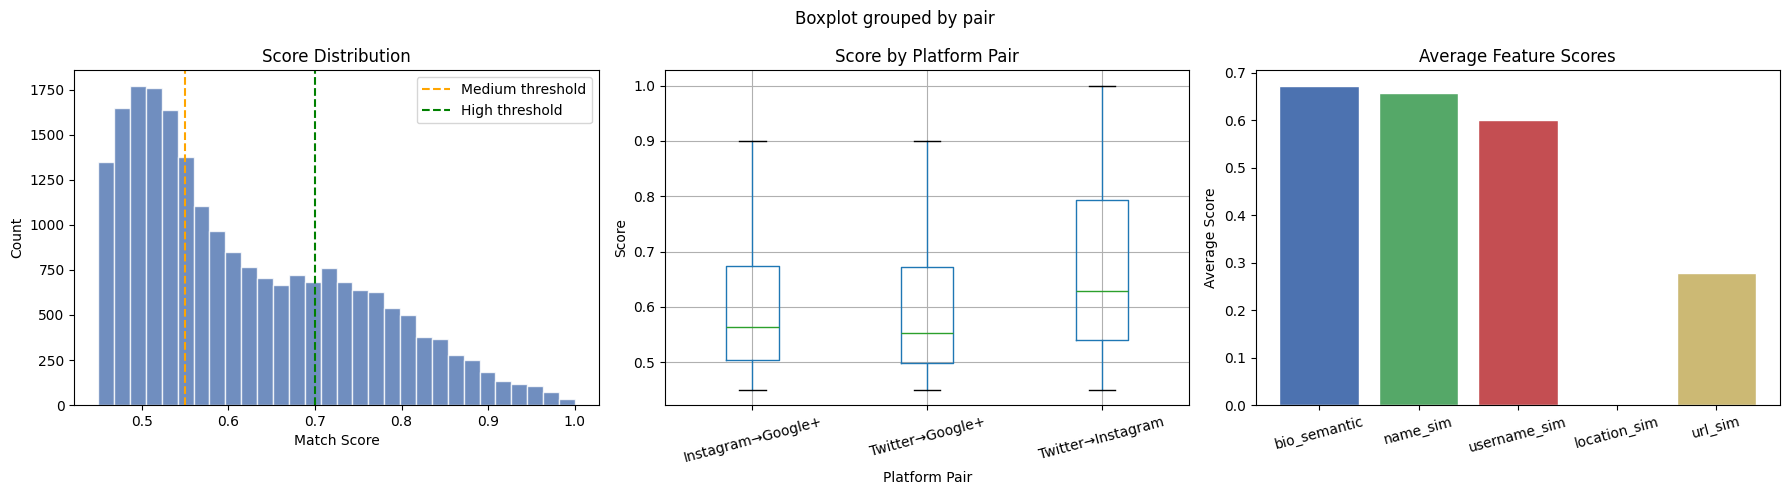

Chart saved to data/matching_results_chart.png


In [17]:
# ===== Visualization =====

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cross-Platform Profile Matching Results (SBERT-MPNet)', fontsize=14, fontweight='bold')

# 1. Score Distribution
axes[0].hist(all_matches['final_score'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.55, color='orange', linestyle='--', label='Medium threshold')
axes[0].axvline(x=0.70, color='green', linestyle='--', label='High threshold')
axes[0].set_xlabel('Match Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()

# 2. Score by Platform Pair
if len(all_matches) > 0:
    all_matches.boxplot(column='final_score', by='pair', ax=axes[1])
    axes[1].set_title('Score by Platform Pair')
    axes[1].set_xlabel('Platform Pair')
    axes[1].set_ylabel('Score')
    plt.sca(axes[1])
    plt.xticks(rotation=15)

# 3. Feature contribution
feature_means = all_matches[['bio_semantic', 'name_sim', 'username_sim', 'location_sim', 'url_sim']].mean()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
axes[2].bar(feature_means.index, feature_means.values, color=colors, edgecolor='white')
axes[2].set_title('Average Feature Scores')
axes[2].set_ylabel('Average Score')
plt.sca(axes[2])
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('data/matching_results_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/matching_results_chart.png')

---
## 7. ค้นหาเฉพาะบุคคล (Single Profile Lookup)

In [20]:
# ===== ค้นหา Profiles ที่คล้ายกับบุคคลใดบุคคลหนึ่ง =====

def find_same_person(profile_idx_or_bio, top_k=10):
    """
    หา profiles ที่น่าจะเป็นคนเดียวกัน จากทุก platform
    
    Args:
        profile_idx_or_bio: index ของ profile ใน df_valid หรือ bio text
        top_k: จำนวนผลลัพธ์
    """
    if isinstance(profile_idx_or_bio, (int, np.integer)):
        idx = profile_idx_or_bio
        source_row = df_valid.iloc[idx]
        q_emb = embeddings[idx:idx+1]
        print(f'🔍 Looking for profiles similar to:')
        print(f'   @{source_row["userName"]} ({source_row["platform"]})')
        print(f'   Name: {safe_str(source_row.get("fullName", ""))}')
        print(f'   Bio: {str(source_row["bio_clean"])[:100]}')
        print(f'   Location: {safe_str(source_row.get("location", ""))}')
    else:
        q_emb = model.encode([profile_idx_or_bio], normalize_embeddings=True).astype(np.float32)
        source_row = None
        print(f'🔍 Looking for profiles matching: "{profile_idx_or_bio[:80]}"')
    
    # Search
    scores, indices = index.search(q_emb, min(top_k * 3, index.ntotal))
    
    results = []
    for bio_sim, tgt_idx in zip(scores[0], indices[0]):
        if tgt_idx < 0:
            continue
        if isinstance(profile_idx_or_bio, (int, np.integer)) and tgt_idx == profile_idx_or_bio:
            continue  # Skip self
        
        target_row = df_valid.iloc[tgt_idx]
        
        if source_row is not None:
            score_detail = compute_match_score(source_row, target_row, float(bio_sim))
        else:
            score_detail = {'final_score': round(float(bio_sim), 4), 'bio_semantic': round(float(bio_sim), 4),
                           'name_sim': 0, 'username_sim': 0, 'location_sim': 0, 'url_sim': 0}
        
        results.append({
            'similarity': score_detail['final_score'],
            'bio_sim': score_detail['bio_semantic'],
            'name_sim': score_detail['name_sim'],
            'userName': target_row['userName'],
            'fullName': safe_str(target_row.get('fullName', '')),
            'platform': target_row['platform'],
            'bio': str(target_row['bio_clean'])[:80],
            'location': safe_str(target_row.get('location', '')),
        })
        
        if len(results) >= top_k:
            break
    
    return pd.DataFrame(results)


# ===== ทดสอบ: หา profiles ที่คล้ายกับ profile แรกที่มี bio =====
first_with_bio = df_valid[df_valid['bio_clean'] != ''].index[0]
find_same_person(first_with_bio, top_k=10)

🔍 Looking for profiles similar to:
   @AALISHANMATRIX (googleplus)
   Name: AALISHAN MATRIX
   Bio: Computer scientist, Aspiring entrepreneur & innovator, Former PHP technical writer, Currently an Gen
   Location: 


,similarity,bio_sim,name_sim,userName,fullName,platform,bio,location
0,0.5325,0.7237,0.3704,faheemalik,Faheem Ahmad,instagram,"Engineer by profession, Entrepreneur by choice...",
1,0.5497,0.7200,0.4286,@alexstanford,Alex Stanford,twitter,"Software Architect, InfoSec Junkie, Web Vision...","Jacksonville, FL"
2,0.5446,0.7169,0.3704,vishaltx,Vishal Kumar,instagram,"Hacker, Innovator and Entrepreneur, Founder / ...",
3,0.5525,0.7085,0.4516,aniskhan001,Anisuzzaman Khan,instagram,"Gamer, Programmer, Problem Solver",
4,0.5070,0.7030,0.3200,@dhilipsiva,dhilipsiva,twitter,"Tech Lead, FullStack & DevOps . I code - a lot...",Bangalore
5,0.5249,0.6973,0.4118,@IsraCV,Israel Cauich Viñas,twitter,"Tech Entrepreneur | Startups, Gadgets, Apps | ...",Mexico
6,0.5334,0.6965,0.4615,@soumikshah,Soumik Shah,twitter,Ex Application Developer at | RT maniac | BLOG...,Los Angeles
7,0.6043,0.6964,0.3846,AssadUllah,Assad Ullah,googleplus,Entrepreneur and Technologist National Univers...,
8,0.4978,0.6934,0.3704,opajdara,Dubie Bacino,instagram,"Internet Entrepreneur, Writer, Psychonaut, Dre...",
9,0.5450,0.6929,0.5714,@rossomakha,masha adamian,twitter,"Co-founder of , Amateur angel investor, Startu...","Palo Alto, CA"


In [21]:
# ===== ค้นหาด้วย Bio text โดยตรง =====
# เปลี่ยน bio_text เป็นอะไรก็ได้ที่ต้องการค้นหา

find_same_person('Data scientist, love AI and machine learning, Bangkok', top_k=10)

🔍 Looking for profiles matching: "Data scientist, love AI and machine learning, Bangkok"


,similarity,bio_sim,name_sim,userName,fullName,platform,bio,location
0,0.6560,0.6560,0,@emredjan,Emre Can,twitter,"MBA Big Data candidate at UvA, aspiring data-s...",Amsterdam
1,0.6338,0.6338,0,@ZhiMerA,ChiM,twitter,"Interested in IT, Marketing, Medicine, Politic...",Bangkok
2,0.6292,0.6292,0,ManishReddyTirumala,Manish Reddy,googleplus,UnderGrad at IIT Bombay. Associate Data Analys...,
3,0.6281,0.6281,0,@AtrHein,Aungthurhahein™,twitter,"Security Engineer, Digital Forensic Researcher...","Bangkok,Yangon"
4,0.6230,0.6230,0,AshishJain33,Ashish Jain,googleplus,"Web Developer, Excel Aficionado & Traveller Gu...",
5,0.6211,0.6211,0,@wrahool,Subhayan Mukerjee,twitter,PhDing . media India networks datascience. Als...,"Philadelphia, PA"
6,0.6190,0.6190,0,@chiragthakkar,Chirag Thakkar,twitter,"The more I know, The less I am.","Ahmadabad City, India"
7,0.6161,0.6161,0,@chethaka,Chéthaka Uduwarage,twitter,"Software Engineer, Computer Science researcher...","Avissawella, Sri Lanka"
8,0.6127,0.6127,0,@kartika9,Kartika Angkawijaya,twitter,"iPhonographer, web developer, and anything in ...",Singapore
9,0.6105,0.6105,0,@robertt89,Roberto Treviño,twitter,MSc in Information Technology ...software deve...,México


---
## 8. บันทึกผลลัพธ์ทั้งหมด

In [22]:
# ===== บันทึก Embeddings + FAISS Index + Matching Results =====

os.makedirs('data/embeddings', exist_ok=True)
os.makedirs('data/matching', exist_ok=True)

# 1. Embeddings
np.save('data/embeddings/bio_mpnet_embeddings.npy', embeddings)
print(f'✅ Embeddings saved: {embeddings.shape} → data/embeddings/bio_mpnet_embeddings.npy')

# 2. FAISS Index
faiss.write_index(index, 'data/embeddings/bio_mpnet_faiss.index')
print(f'✅ FAISS Index saved: {index.ntotal:,} vectors → data/embeddings/bio_mpnet_faiss.index')

# 3. Metadata (สำหรับ map กลับไปหา profile)
df_valid[['userName', 'fullName', 'platform', 'bio_clean', 'location', 'enriched_text']].to_csv(
    'data/embeddings/bio_mpnet_metadata.csv', index=False, encoding='utf-8-sig'
)
print(f'✅ Metadata saved: {len(df_valid):,} rows → data/embeddings/bio_mpnet_metadata.csv')

# 4. Matching Results
if len(all_matches) > 0:
    all_matches.to_csv('data/matching/cross_platform_matches.csv', index=False, encoding='utf-8-sig')
    print(f'✅ Matches saved: {len(all_matches):,} pairs → data/matching/cross_platform_matches.csv')
    
    # High confidence matches only
    high_conf = all_matches[all_matches['final_score'] >= 0.55]
    high_conf.to_csv('data/matching/high_confidence_matches.csv', index=False, encoding='utf-8-sig')
    print(f'✅ High-confidence matches: {len(high_conf):,} pairs → data/matching/high_confidence_matches.csv')

# 5. Profiles with embeddings (enriched dataset)
df_valid.to_csv('data/profiles_with_enriched_text.csv', index=False, encoding='utf-8-sig')
print(f'✅ Enriched profiles: {len(df_valid):,} rows → data/profiles_with_enriched_text.csv')

print(f'\n🎉 ทุกอย่างบันทึกเรียบร้อย!')
print(f'\n--- สรุปไฟล์ที่สร้าง ---')
print(f'  data/embeddings/bio_mpnet_embeddings.npy     - Embedding vectors {embeddings.shape}')
print(f'  data/embeddings/bio_mpnet_faiss.index        - FAISS index สำหรับ search')
print(f'  data/embeddings/bio_mpnet_metadata.csv       - Mapping ระหว่าง index ↔ profile')
print(f'  data/matching/cross_platform_matches.csv     - ผล matching ทั้งหมด')
print(f'  data/matching/high_confidence_matches.csv    - เฉพาะ matches ที่มั่นใจสูง')
print(f'  data/profiles_with_enriched_text.csv         - Profiles + enriched text')

✅ Embeddings saved: (24530, 768) → data/embeddings/bio_mpnet_embeddings.npy
✅ FAISS Index saved: 24,530 vectors → data/embeddings/bio_mpnet_faiss.index
✅ Metadata saved: 24,530 rows → data/embeddings/bio_mpnet_metadata.csv
✅ Matches saved: 21,683 pairs → data/matching/cross_platform_matches.csv
✅ High-confidence matches: 12,846 pairs → data/matching/high_confidence_matches.csv
✅ Enriched profiles: 24,530 rows → data/profiles_with_enriched_text.csv

🎉 ทุกอย่างบันทึกเรียบร้อย!

--- สรุปไฟล์ที่สร้าง ---
  data/embeddings/bio_mpnet_embeddings.npy     - Embedding vectors (24530, 768)
  data/embeddings/bio_mpnet_faiss.index        - FAISS index สำหรับ search
  data/embeddings/bio_mpnet_metadata.csv       - Mapping ระหว่าง index ↔ profile
  data/matching/cross_platform_matches.csv     - ผล matching ทั้งหมด
  data/matching/high_confidence_matches.csv    - เฉพาะ matches ที่มั่นใจสูง
  data/profiles_with_enriched_text.csv         - Profiles + enriched text
